In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import pickle

with open(f"activations_save/activations_vit_cifar100_rank.pkl", "rb") as f:
    activations = pickle.load(f)

In [4]:
activations.keys()

dict_keys(['layer_0.input_layernorm', 'layer_0.self_attn_k_proj', 'layer_0.self_attn_v_proj', 'layer_0.self_attn_q_proj', 'layer_0.self_attn_o_proj', 'layer_0.post_attention_layernorm', 'layer_0.mlp_gate_proj', 'layer_0.mlp_up_proj', 'layer_0.mlp_down_proj', 'layer_1.input_layernorm', 'layer_1.self_attn_k_proj', 'layer_1.self_attn_v_proj', 'layer_1.self_attn_q_proj', 'layer_1.self_attn_o_proj', 'layer_1.post_attention_layernorm', 'layer_1.mlp_gate_proj', 'layer_1.mlp_up_proj', 'layer_1.mlp_down_proj', 'layer_2.input_layernorm', 'layer_2.self_attn_k_proj', 'layer_2.self_attn_v_proj', 'layer_2.self_attn_q_proj', 'layer_2.self_attn_o_proj', 'layer_2.post_attention_layernorm', 'layer_2.mlp_gate_proj', 'layer_2.mlp_up_proj', 'layer_2.mlp_down_proj', 'layer_3.input_layernorm', 'layer_3.self_attn_k_proj', 'layer_3.self_attn_v_proj', 'layer_3.self_attn_q_proj', 'layer_3.self_attn_o_proj', 'layer_3.post_attention_layernorm', 'layer_3.mlp_gate_proj', 'layer_3.mlp_up_proj', 'layer_3.mlp_down_proj

In [5]:
activations['layer_0.self_attn_o_proj']['input'][0].shape

torch.Size([16, 197, 768])

X2d: (3152, 768) C= 768
mean: min/max = -0.02020161971449852 0.09484579414129257
std : min/max = 0.13532139360904694 0.3645385801792145
val : min/max = -1.7211121320724487 2.846912145614624


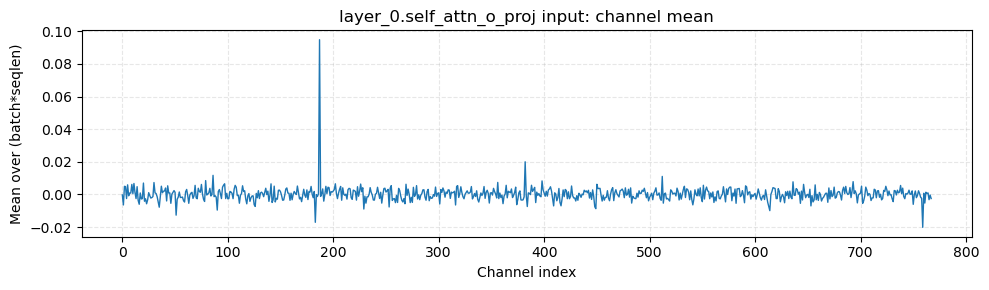

Outliers by zscore (mean): [187]
Outliers by MAD    (mean): [187]
ch 0187 | mean=0.0948458 std=0.364539 min=-0.825572 max=1.59


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def channel_stats(x: torch.Tensor):
    """
    x: [..., C]，最后一维视为 channel
    返回：mean/std/min/max（按 channel），以及展平后的 X2d: [N, C]
    """
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    x = x.detach()

    # 展平 batch*seqlen*... -> N
    C = x.shape[-1]
    X2d = x.reshape(-1, C).to(torch.float32)

    mean = X2d.mean(dim=0)
    std  = X2d.std(dim=0, unbiased=False)
    vmin = X2d.min(dim=0).values
    vmax = X2d.max(dim=0).values
    return X2d, mean, std, vmin, vmax

def detect_outlier_channels_by_mean(mean: torch.Tensor, method="zscore", z_th=5.0, mad_th=10.0):
    """
    基于每个 channel 的 mean 来找异常 channel
    - method="zscore": |(mean-mean(mean))/std(mean)| > z_th
    - method="mad":    |(mean-median)/MAD| > mad_th (更稳健)
    返回：outlier_indices (LongTensor), score (Tensor)
    """
    m = mean.to(torch.float32)

    if method == "zscore":
        mu = m.mean()
        sd = m.std(unbiased=False) + 1e-12
        score = (m - mu).abs() / sd
        out = torch.nonzero(score > z_th, as_tuple=False).squeeze(1)
        return out, score

    if method == "mad":
        med = m.median()
        mad = (m - med).abs().median() + 1e-12
        score = (m - med).abs() / mad
        out = torch.nonzero(score > mad_th, as_tuple=False).squeeze(1)
        return out, score

    raise ValueError(f"Unknown method: {method}")

def plot_channel_means(mean: torch.Tensor, title="Channel mean"):
    mean_np = mean.cpu().numpy()
    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(len(mean_np)), mean_np, linewidth=1)
    plt.xlabel("Channel index")
    plt.ylabel("Mean over (batch*seqlen)")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ====== 用法示例：挑一个你关心的激活张量 ======
x = activations["layer_8.self_attn_q_proj"]["input"][0]  # shape: [B, ..., C]
x = x.reshape(-1, x.shape[-1])  # 转成 [N, C] 方便查看
# x = x.T
U, S, VT = torch.linalg.svd(x.to(torch.float32), full_matrices=False)
k=32
R = x - U[:, :k] @ torch.diag(S[:k]) @ VT[:k, :]
X2d, mean, std, vmin, vmax = channel_stats(R)

print("X2d:", tuple(X2d.shape), "C=", X2d.shape[1])
print("mean: min/max =", mean.min().item(), mean.max().item())
print("std : min/max =", std.min().item(),  std.max().item())
print("val : min/max =", vmin.min().item(), vmax.max().item())

plot_channel_means(mean, title="layer_0.self_attn_o_proj input: channel mean")

# 异常 channel（两种判别任选）
out_z, score_z = detect_outlier_channels_by_mean(mean, method="zscore", z_th=5.0)
out_m, score_m = detect_outlier_channels_by_mean(mean, method="mad", mad_th=10.0)

print("Outliers by zscore (mean):", out_z.tolist())
print("Outliers by MAD    (mean):", out_m.tolist())

# 进一步：打印异常 channel 的更详细统计
def print_channels_detail(ch_idx):
    for c in ch_idx:
        c = int(c)
        print(f"ch {c:04d} | mean={mean[c].item():.6g} std={std[c].item():.6g} min={vmin[c].item():.6g} max={vmax[c].item():.6g}")

print_channels_detail(out_m[:20])  # 只打印前20个

In [7]:
activations['layer_0.mlp_gate_proj']['input'][0].shape

torch.Size([16, 197, 768])

In [8]:
def analyze_output_singular_values(layer_name):
    # 一共有12层，把每一层的输出奇异值分布绘制到一张图上，折线图形式
    layer_indices = []
    layer_avg_svs = []
    
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])  # e.g., "layers.0"
        # outputs = activations[layer]["output"]  # list of tensors

        # total_singular_values = 0
        
        # for output in outputs:
        #     tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        #     if not isinstance(tensor, torch.Tensor):
        #         continue
        #     singular_values = torch.linalg.svdvals(tensor)
        #     total_singular_values += singular_values.sum().item()
            
        # avg_singular_value = total_singular_values / len(outputs)
        
        # layer_indices.append(layer_id)
        # layer_avg_svs.append(avg_singular_value)
        
        output = activations[layer]["input"][0]
        tensor = output.reshape(-1, output.shape[-1]).to(torch.float32).to(device)
        # U, S, Vh = torch.linalg.svd(tensor, full_matrices=False)
        singular_values = torch.linalg.svdvals(tensor)
        
        layer_indices.append(layer_id)
        layer_avg_svs.append(singular_values)
        
    return layer_indices, layer_avg_svs


In [9]:
def plot_singular_value_distribution(layer_ids, layer_svs, layer_name):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv.cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-3
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [10]:
def plot_singular_value_topX_distribution(layer_ids, layer_svs, layer_name, X=10):
    plt.figure(figsize=(10, 6))
    
    cmap = plt.cm.get_cmap("viridis", len(layer_ids))
    colors = [cmap(i) for i in range(len(layer_ids))]

    for layer_id, sv, color in zip(layer_ids, layer_svs, colors):
        sv = sv[:X].cpu().numpy()
        x = range(len(sv))            # 奇异值索引
        plt.plot(x, sv, label=f"layer {layer_id}", color=color)

    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.title(f"Singular value spectra across layers for {layer_name} top {X}")
    plt.grid(True)
    
    plt.yscale("log")  # 如果差距太大，用对数坐标更清晰；不想用可以删掉这一行
    # ymin = 1e-1
    max_sv = max(sv.max().item() for sv in layer_svs)
    ymax = 10 ** math.ceil(math.log10(max_sv))
    plt.ylim(top=ymax)

    # 图例放到右侧，避免挡住曲线
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

In [11]:
layer_name = "attn_q_proj"
layer_ids, layer_svs = analyze_output_singular_values(layer_name)

/tmp/ipykernel_170421/3106386022.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


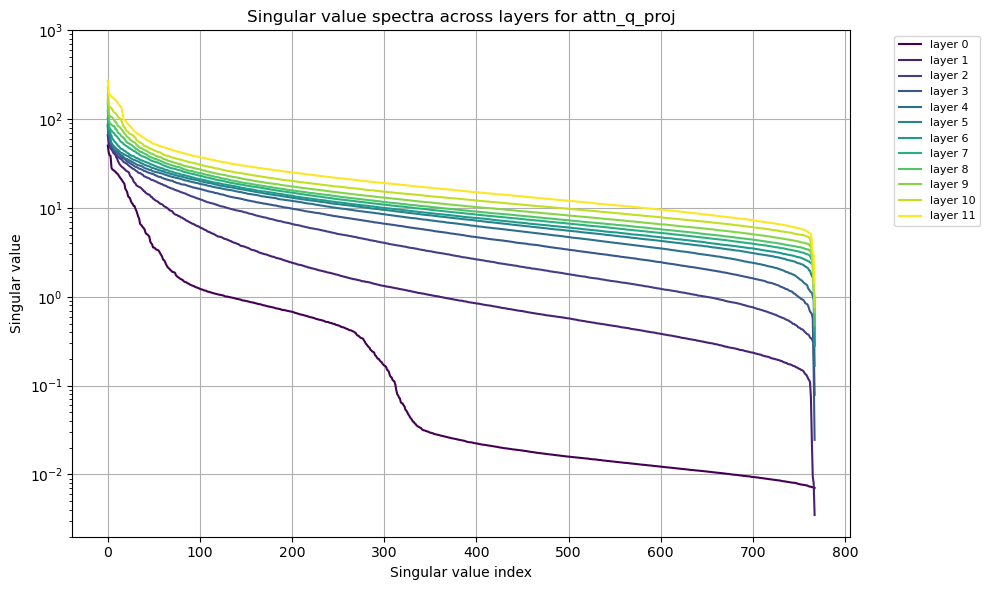

In [12]:
plot_singular_value_distribution(layer_ids, layer_svs, 'attn_q_proj')

/tmp/ipykernel_170421/3210539342.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(layer_ids))


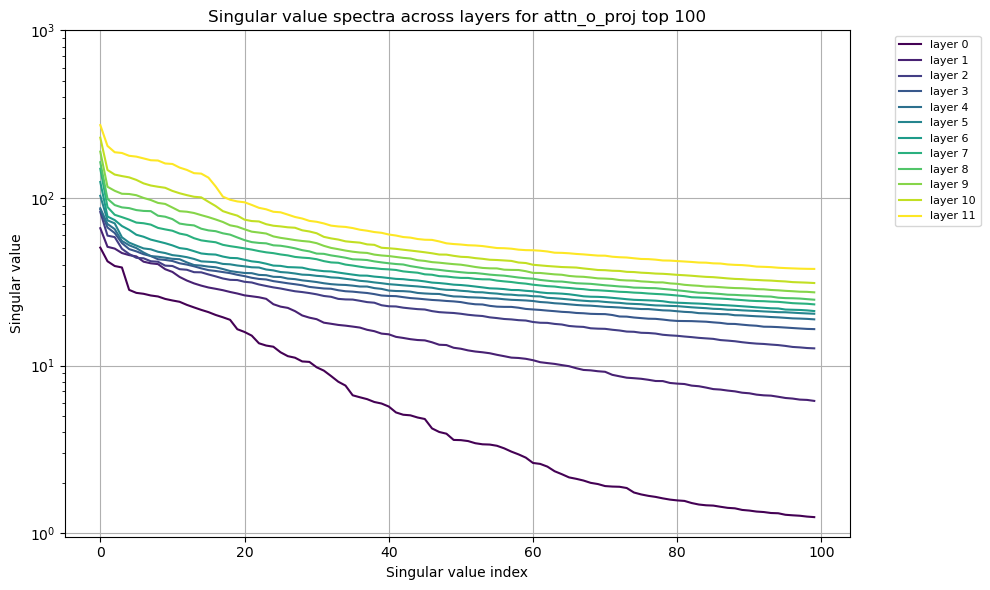

In [13]:
plot_singular_value_topX_distribution(layer_ids, layer_svs, 'attn_o_proj', X=100)

In [14]:
import math
import numpy as np

def cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0):
    sv_dict = {}
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])
        x = activations[layer][io_key][sample_idx]
        X = x.reshape(-1, x.shape[-1]).to(torch.float32).to(device)
        sv = torch.linalg.svdvals(X).cpu()
        sv_dict[layer_id] = sv
    return sv_dict

def analyze_energy_ratio_from_sv_cache(sv_cache, rank_ratio):
    layer_ids, ratios, ks, totals = [], [], [], []
    for layer_id in sorted(sv_cache.keys()):
        sv = sv_cache[layer_id]
        k = max(1, int(math.ceil(len(sv) * rank_ratio)))
        energy = sv.pow(2)
        # energy = sv
        total = energy.sum()
        topk = energy[:k].sum()
        ratio = (topk / (total + 1e-12)).item()
        layer_ids.append(layer_id)
        ratios.append(ratio)
        ks.append(k)
        totals.append(total.item())
    return layer_ids, ratios, ks, totals

def plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio):
    plt.figure(figsize=(8, 4))
    plt.plot(layer_ids, ratios, marker="o")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: rank_ratio={rank_ratio} energy capture")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
# 只需SVD一次，缓存所有层的奇异值
mlp_layer_name = "mlp_gate_proj"  # 例如："mlp_gate_proj"、"self_attn_o_proj"等
mlp_sv_cache = cache_all_layer_singular_values(mlp_layer_name, io_key="input", sample_idx=0)

In [16]:
# 只需SVD一次，缓存所有层的奇异值
attn_layer_name = "self_attn_q_proj"  # 例如："mlp_gate_proj"、"self_attn_o_proj"等
attn_q_proj_sv_cache = cache_all_layer_singular_values(attn_layer_name, io_key="input", sample_idx=0)

[0.8471304774284363, 0.7004435658454895, 0.6145258545875549, 0.5222192406654358, 0.49295228719711304, 0.47730472683906555, 0.4861772060394287, 0.5039480328559875, 0.5276622772216797, 0.5573888421058655, 0.6215353608131409, 0.781391978263855]


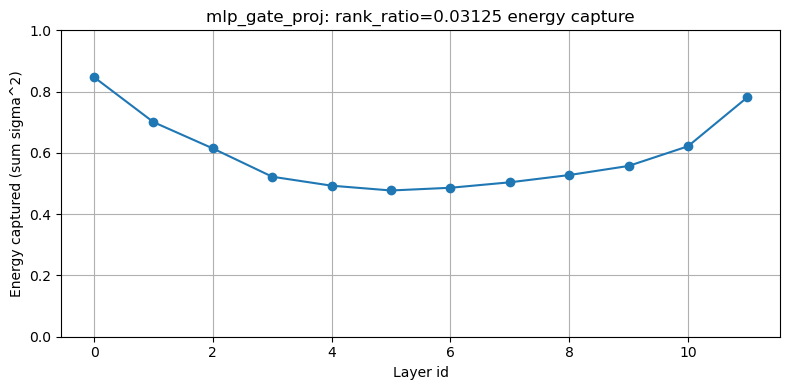

In [17]:
# mlp
rank_ratio = 1 / 32.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

# for lid, r, k in zip(layer_ids, ratios, ks):
#     print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

print(ratios)

plot_energy_ratios(layer_ids, ratios, mlp_layer_name, rank_ratio)

[0.9517152905464172, 0.8316370844841003, 0.7386111617088318, 0.6518255472183228, 0.6177206635475159, 0.6075810194015503, 0.6200477480888367, 0.6384006142616272, 0.6576208472251892, 0.680418848991394, 0.7265080213546753, 0.8364335298538208]


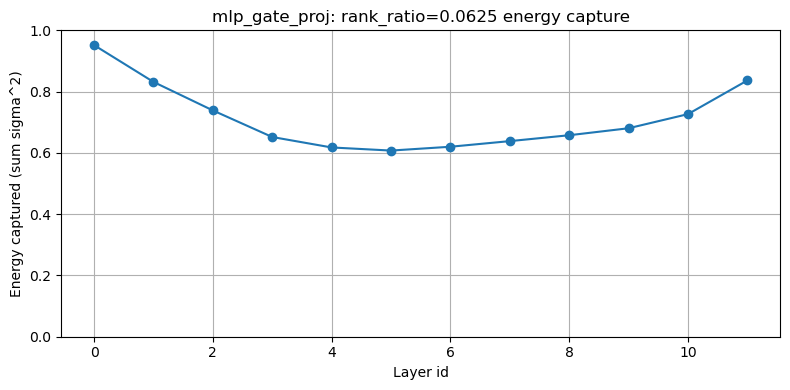

In [18]:
# mlp
rank_ratio = 1 / 16.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

print(ratios)

plot_energy_ratios(layer_ids, ratios, mlp_layer_name, rank_ratio)

[0.9884421229362488, 0.9292758107185364, 0.8576378226280212, 0.7872541546821594, 0.7536465525627136, 0.7415376305580139, 0.7504402995109558, 0.765192449092865, 0.7776041030883789, 0.7901283502578735, 0.8170145750045776, 0.8877151012420654]


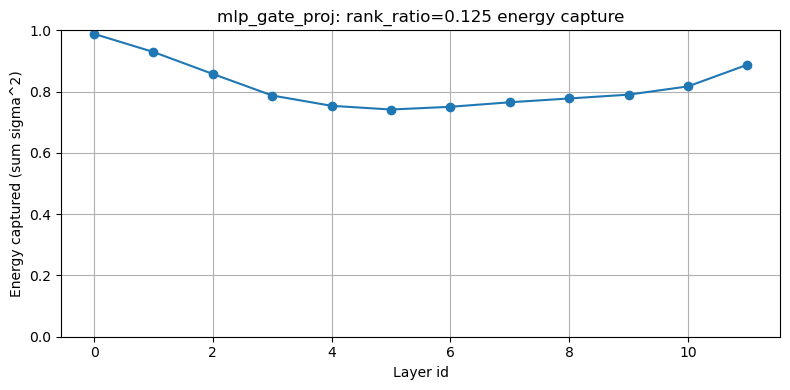

In [19]:
# mlp
rank_ratio = 1 / 8.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(mlp_sv_cache, rank_ratio)

print(ratios)

plot_energy_ratios(layer_ids, ratios, mlp_layer_name, rank_ratio)

[0.9985615611076355, 0.9878467321395874, 0.9406263828277588, 0.8842058777809143, 0.8437860012054443, 0.8309342265129089, 0.838971734046936, 0.8499498963356018, 0.8583651185035706, 0.8637310862541199, 0.8669913411140442, 0.8756096363067627]


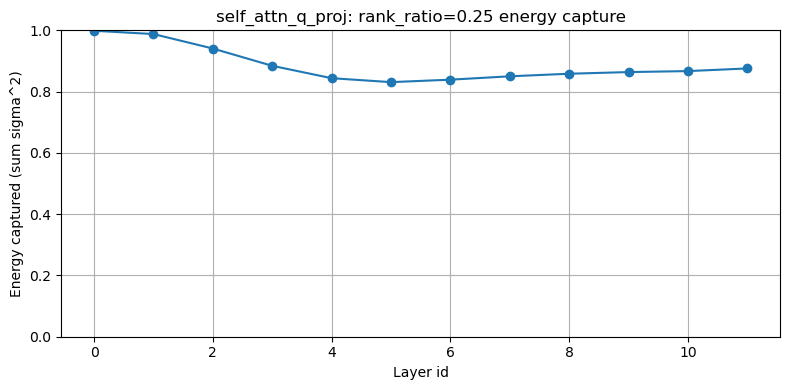

In [20]:
# attn
rank_ratio = 1 / 4.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

print(ratios)

plot_energy_ratios(layer_ids, ratios, attn_layer_name, rank_ratio)

layer 00: k=48, energy_ratio=0.9806
layer 01: k=48, energy_ratio=0.8649
layer 02: k=48, energy_ratio=0.6818
layer 03: k=48, energy_ratio=0.5792
layer 04: k=48, energy_ratio=0.5184
layer 05: k=48, energy_ratio=0.5139
layer 06: k=48, energy_ratio=0.5410
layer 07: k=48, energy_ratio=0.5733
layer 08: k=48, energy_ratio=0.6006
layer 09: k=48, energy_ratio=0.6255
layer 10: k=48, energy_ratio=0.6501
layer 11: k=48, energy_ratio=0.6807


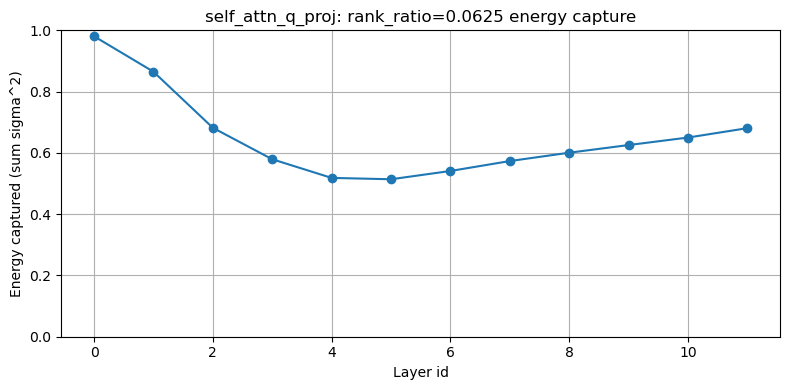

In [21]:
# attn
rank_ratio = 1 / 16.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, attn_layer_name, rank_ratio)

layer 00: k=96, energy_ratio=0.9939
layer 01: k=96, energy_ratio=0.9529
layer 02: k=96, energy_ratio=0.8375
layer 03: k=96, energy_ratio=0.7442
layer 04: k=96, energy_ratio=0.6861
layer 05: k=96, energy_ratio=0.6761
layer 06: k=96, energy_ratio=0.6960
layer 07: k=96, energy_ratio=0.7192
layer 08: k=96, energy_ratio=0.7378
layer 09: k=96, energy_ratio=0.7518
layer 10: k=96, energy_ratio=0.7636
layer 11: k=96, energy_ratio=0.7806


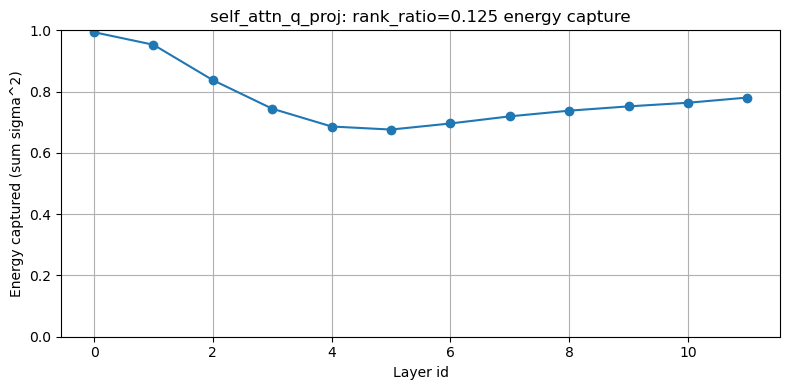

In [22]:
# attn
rank_ratio = 1 / 8.0
layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(attn_q_proj_sv_cache, rank_ratio)

for lid, r, k in zip(layer_ids, ratios, ks):
    print(f"layer {lid:02d}: k={k}, energy_ratio={r:.4f}")

plot_energy_ratios(layer_ids, ratios, attn_layer_name, rank_ratio)

[0.8471304774284363, 0.7004435658454895, 0.6145258545875549, 0.5222192406654358, 0.49295228719711304, 0.47730472683906555, 0.4861772060394287, 0.5039480328559875, 0.5276622772216797, 0.5573888421058655, 0.6215353608131409, 0.781391978263855]
[0.9517152905464172, 0.8316370844841003, 0.7386111617088318, 0.6518255472183228, 0.6177206635475159, 0.6075810194015503, 0.6200477480888367, 0.6384006142616272, 0.6576208472251892, 0.680418848991394, 0.7265080213546753, 0.8364335298538208]
[0.9884421229362488, 0.9292758107185364, 0.8576378226280212, 0.7872541546821594, 0.7536465525627136, 0.7415376305580139, 0.7504402995109558, 0.765192449092865, 0.7776041030883789, 0.7901283502578735, 0.8170145750045776, 0.8877151012420654]
[0.9972967505455017, 0.9811333417892456, 0.9450920820236206, 0.9020441770553589, 0.8754847049713135, 0.8648802042007446, 0.8676252365112305, 0.8748651742935181, 0.8803258538246155, 0.8851944804191589, 0.8972830176353455, 0.9362018704414368]


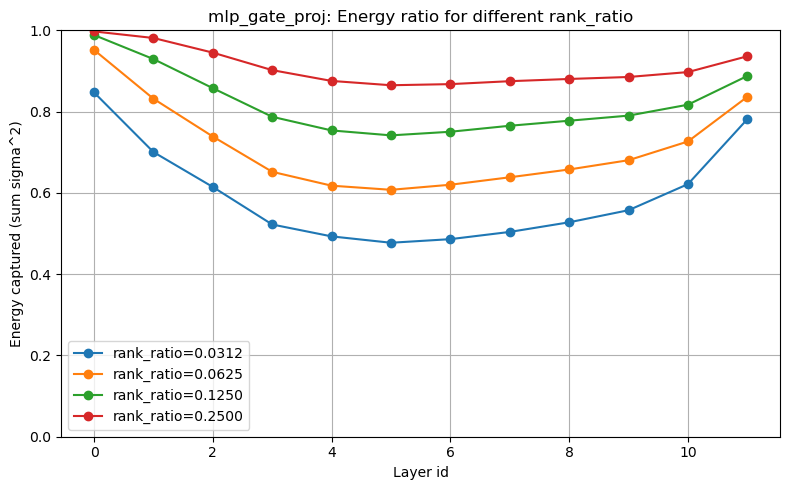

In [23]:
def plot_multi_rank_energy_ratios(sv_cache, layer_name, rank_ratios, legend_loc="best"):
    plt.figure(figsize=(8, 5))
    for rr in rank_ratios:
        layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(sv_cache, rr)
        print(ratios)
        plt.plot(layer_ids, ratios, marker="o", label=f"rank_ratio={rr:.4f}")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: Energy ratio for different rank_ratio")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()

# 示例用法
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(mlp_sv_cache, "mlp_gate_proj", rank_ratios)

[0.8978355526924133, 0.7118636965751648, 0.5098859667778015, 0.4228358268737793, 0.3701263964176178, 0.36674225330352783, 0.39595523476600647, 0.42716917395591736, 0.45690780878067017, 0.48900339007377625, 0.5238165259361267, 0.5711145997047424]
[0.9805543422698975, 0.864938497543335, 0.6818300485610962, 0.5792053937911987, 0.5183933973312378, 0.5139405727386475, 0.5409577488899231, 0.5733326077461243, 0.6005847454071045, 0.6255450248718262, 0.6500610113143921, 0.6806831955909729]
[0.9938580393791199, 0.9529260396957397, 0.8374728560447693, 0.744190514087677, 0.6861188411712646, 0.6761419773101807, 0.695990264415741, 0.719248354434967, 0.7377941608428955, 0.7518313527107239, 0.7636304497718811, 0.7805972099304199]
[0.9985615611076355, 0.9878467321395874, 0.9406263828277588, 0.8842058777809143, 0.8437860012054443, 0.8309342265129089, 0.838971734046936, 0.8499498963356018, 0.8583651185035706, 0.8637310862541199, 0.8669913411140442, 0.8756096363067627]


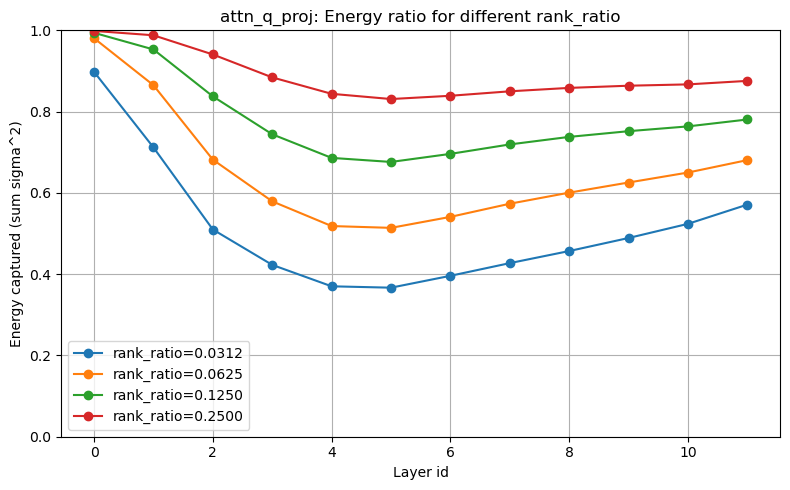

In [24]:
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(attn_q_proj_sv_cache, "attn_q_proj", rank_ratios)

In [25]:
from meft.linalg.qb import randomized_qb

/home/shijx/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
activations.keys()

dict_keys(['layer_0.input_layernorm', 'layer_0.self_attn_k_proj', 'layer_0.self_attn_v_proj', 'layer_0.self_attn_q_proj', 'layer_0.self_attn_o_proj', 'layer_0.post_attention_layernorm', 'layer_0.mlp_gate_proj', 'layer_0.mlp_up_proj', 'layer_0.mlp_down_proj', 'layer_1.input_layernorm', 'layer_1.self_attn_k_proj', 'layer_1.self_attn_v_proj', 'layer_1.self_attn_q_proj', 'layer_1.self_attn_o_proj', 'layer_1.post_attention_layernorm', 'layer_1.mlp_gate_proj', 'layer_1.mlp_up_proj', 'layer_1.mlp_down_proj', 'layer_2.input_layernorm', 'layer_2.self_attn_k_proj', 'layer_2.self_attn_v_proj', 'layer_2.self_attn_q_proj', 'layer_2.self_attn_o_proj', 'layer_2.post_attention_layernorm', 'layer_2.mlp_gate_proj', 'layer_2.mlp_up_proj', 'layer_2.mlp_down_proj', 'layer_3.input_layernorm', 'layer_3.self_attn_k_proj', 'layer_3.self_attn_v_proj', 'layer_3.self_attn_q_proj', 'layer_3.self_attn_o_proj', 'layer_3.post_attention_layernorm', 'layer_3.mlp_gate_proj', 'layer_3.mlp_up_proj', 'layer_3.mlp_down_proj

In [28]:
tensor = activations['layer_11.self_attn_q_proj']["input"][0].reshape(-1, activations['layer_11.self_attn_q_proj']["input"][0].shape[-1]).to(torch.float32).to(device)
print(tensor.shape)

Q, B = randomized_qb(tensor, rank=128)

torch.Size([3152, 768])


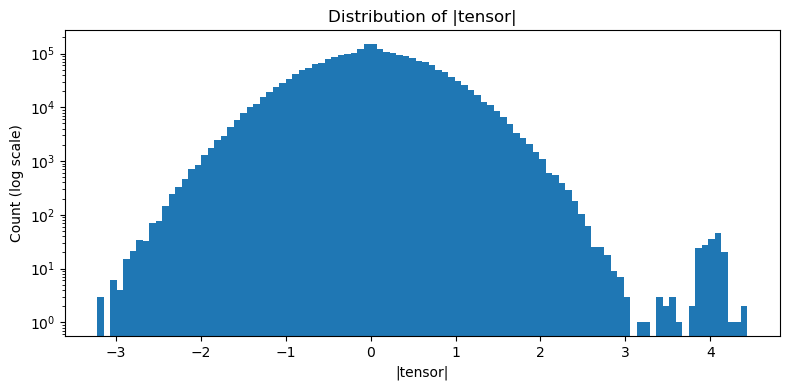

In [37]:
tensor_flat = tensor.detach().reshape(-1).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(tensor_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|tensor|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |tensor|")
plt.tight_layout()
plt.show()

In [29]:
Q.shape, B.shape

(torch.Size([3152, 128]), torch.Size([128, 768]))

In [30]:
R = tensor - Q @ B
R.shape
R

tensor([[-0.3756,  0.3302, -0.0917,  ...,  0.1199, -0.3002, -0.4118],
        [-0.0414,  0.1255,  0.6915,  ...,  0.1075,  0.3450, -0.0931],
        [-0.2821,  0.4219, -0.1284,  ...,  0.0469,  0.1982, -0.3149],
        ...,
        [ 0.5041, -0.3931, -0.4165,  ...,  0.3649,  0.1366,  0.1135],
        [ 0.6649, -0.0249, -0.1313,  ...,  0.2272,  0.2653, -0.1497],
        [ 0.0579,  0.0426,  0.0579,  ..., -0.0448,  0.0116, -0.0151]],
       device='cuda:0')

In [31]:
R.max(), R.min(), R.mean(), R.std()

(tensor(3.3978, device='cuda:0'),
 tensor(-2.0075, device='cuda:0'),
 tensor(0.0002, device='cuda:0'),
 tensor(0.3006, device='cuda:0'))

In [32]:
torch.sum(R.abs() > 1e-2)

tensor(2334161, device='cuda:0')

R stats: min = -2.0075302 max = 3.3978488 mean = 0.00018014113


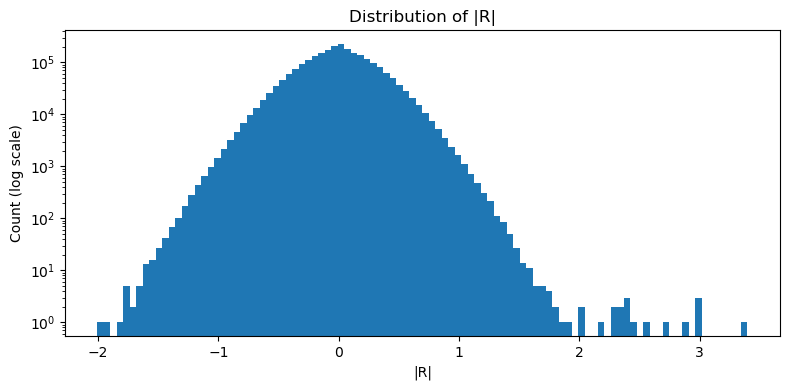

In [33]:
import numpy as np

R_flat = R.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

print("R stats:",
      "min =", R_flat.min(),
      "max =", R_flat.max(),
      "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(R_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|R|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |R|")
plt.tight_layout()
plt.show()

In [39]:
R.shape

torch.Size([3152, 768])

In [40]:
import bitsandbytes as bnb

quant_state = bnb.functional.quantize_4bit(
    R,
    quant_type="nf4",  # 指定 NF4 格式（适配正态分布的 R）
    blocksize=256,      # 分块量化，平衡精度/速度
    # blocksize=R.shape[-1],
    compress_statistics=True
)

R_nf4_dequant = bnb.functional.dequantize_4bit(*quant_state)

mse = torch.mean((R - R_nf4_dequant)**2)
print(f"NF4 量化 MSE: {mse.item()}")

mae = torch.mean(torch.abs(R - R_nf4_dequant))
print(f"NF4 量化 MAE: {mae.item()}")

NF4 量化 MSE: 0.0009109682287089527
NF4 量化 MAE: 0.023832250386476517


In [41]:
import math
import torch
import torch.nn.functional as F

def _is_power_of_two(n: int) -> bool:
    return n > 0 and (n & (n - 1)) == 0

def fwht_lastdim(x: torch.Tensor, normalize: bool = True) -> torch.Tensor:
    """
    Fast Walsh–Hadamard Transform along last dimension.
    要求 x.shape[-1] 是 2 的幂。
    """
    n = x.shape[-1]
    if not _is_power_of_two(n):
        raise ValueError(f"FWHT requires power-of-two length, got {n}")

    y = x
    h = 1
    while h < n:
        # reshape: [..., n/(2h), 2h]
        y = y.reshape(*y.shape[:-1], n // (2 * h), 2 * h)
        a = y[..., :h]
        b = y[..., h:2 * h]
        y = torch.cat([a + b, a - b], dim=-1)
        y = y.reshape(*y.shape[:-2], n)
        h *= 2

    if normalize:
        y = y / math.sqrt(n)
    return y

def hadamard_transform_768(x: torch.Tensor, pad_to: int = 1024, keep_padded: bool = False) -> torch.Tensor:
    """
    对 [..., 768] 做 Hadamard：先 pad 到 pad_to(默认1024) 再 FWHT。
    keep_padded=False: 返回 [..., 768]
    keep_padded=True : 返回 [..., pad_to]
    """
    if x.shape[-1] != 768:
        raise ValueError(f"Expected last dim 768, got {x.shape[-1]}")
    if not _is_power_of_two(pad_to) or pad_to < 768:
        raise ValueError(f"pad_to must be power-of-two and >= 768, got {pad_to}")

    x_pad = F.pad(x, (0, pad_to - 768))  # pad last dim
    y_pad = fwht_lastdim(x_pad, normalize=True)
    return y_pad if keep_padded else y_pad[..., :768]

# === 用法 ===
# X = torch.randn(3152, 768, device="cuda", dtype=torch.float16)
Y = hadamard_transform_768(tensor, pad_to=1024, keep_padded=False)
print(Y.shape)  # torch.Size([3152, 768])

torch.Size([3152, 768])


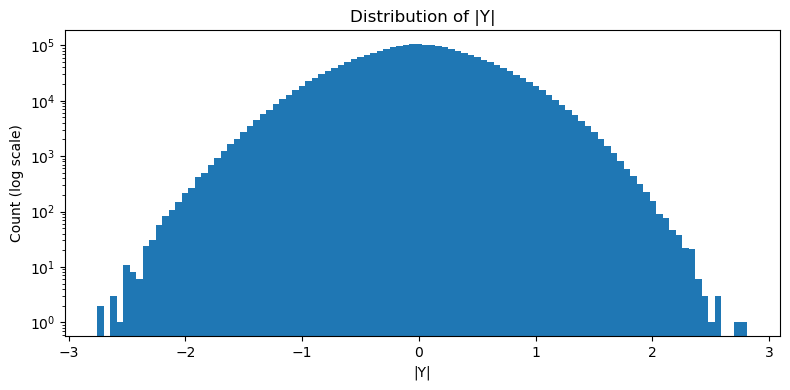

In [42]:
import numpy as np

Y_flat = Y.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

# print("R stats:",
#       "min =", R_flat.min(),
#       "max =", R_flat.max(),
#       "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(Y_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|Y|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |Y|")
plt.tight_layout()
plt.show()

In [43]:
Q, B = randomized_qb(Y, rank=128)

In [44]:
R = Y - Q @ B
R.shape
R

tensor([[ 0.0904, -0.0189, -0.0389,  ...,  0.2201,  0.1041,  0.2654],
        [-0.0541, -0.0080, -0.0759,  ..., -0.1916, -0.6800,  0.2392],
        [ 0.0761, -0.0892,  0.6284,  ..., -0.5734,  0.1447, -0.3299],
        ...,
        [-0.0071, -0.0595,  0.2314,  ..., -0.2768, -0.1360,  0.2548],
        [-0.0070, -0.0561,  0.4366,  ..., -0.4519, -0.2806,  0.5878],
        [ 0.0468,  0.1047,  0.0062,  ..., -0.0173, -0.0700,  0.1044]],
       device='cuda:0')

R stats: min = -1.5932223 max = 1.7028887 mean = 0.00019590132


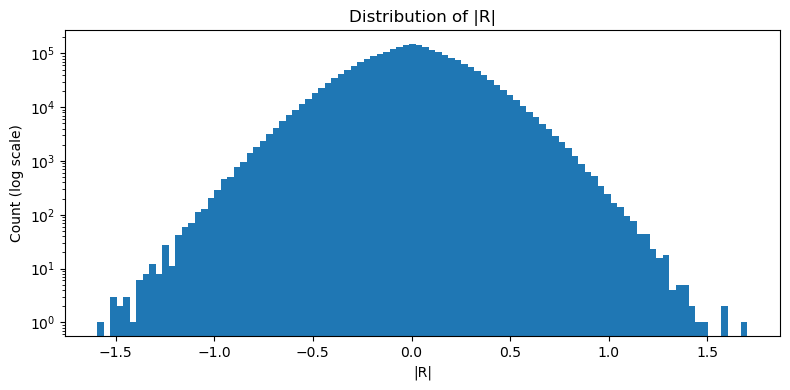

In [45]:
import numpy as np

R_flat = R.detach().reshape(-1).cpu().numpy()  # 取绝对值再拉平

print("R stats:",
      "min =", R_flat.min(),
      "max =", R_flat.max(),
      "mean =", R_flat.mean())

plt.figure(figsize=(8, 4))
plt.hist(R_flat, bins=100, log=True)   # y 轴用 log，看尾部更清楚
# plt.hist(R_flat, bins=100, log=False)
plt.xlabel("|R|")
plt.ylabel("Count (log scale)")
plt.title("Distribution of |R|")
plt.tight_layout()
plt.show()

In [46]:
import bitsandbytes as bnb

quant_state = bnb.functional.quantize_4bit(
    R,
    quant_type="nf4",  # 指定 NF4 格式（适配正态分布的 R）
    blocksize=256,      # 分块量化，平衡精度/速度
    # blocksize=R.shape[-1],
    compress_statistics=True
)

R_nf4_dequant = bnb.functional.dequantize_4bit(*quant_state)

mse = torch.mean((R - R_nf4_dequant)**2)
print(f"NF4 量化 MSE: {mse.item()}")

mae = torch.mean(torch.abs(R - R_nf4_dequant))
print(f"NF4 量化 MAE: {mae.item()}")

NF4 量化 MSE: 0.0006408414919860661
NF4 量化 MAE: 0.02004629746079445
